
# Spatial Data



## Getting ready


### Libraries needed

Let's verify:

In [1]:
!pip show pysal pandas geopandas

Name: pysal
Version: 26.1
Summary: Meta Package for PySAL - A library of spatial analysis functions
Home-page: 
Author: 
Author-email: Serge Rey <sjsrey@gmail.com>, Levi Wolf <levi.john.wolf@gmail.com>
License: BSD 3-Clause
Location: /opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages
Requires: access, beautifulsoup4, esda, geopandas, giddy, gwlearn, inequality, lazy_loader, libpysal, mapclassify, mgwr, momepy, numpy, packaging, pandas, platformdirs, pointpats, requests, scikit-learn, scipy, segregation, shapely, spaghetti, spglm, spint, splot, spopt, spreg, tobler
Required-by: 
---
Name: pandas
Version: 2.3.3
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License

 Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
 All rights reserved.

 Copyright (c) 2011-

In [ ]:
## needed in Colab
# !pip install pysal

### Data to use



A map of Peru, at the **'distrito'** level (similar to municipality in the USA - not exactly the same). The map comes from an unoffical [website](https://www.geogpsperu.com/p/descargas.html). Some columns with **social data** have been added. This will be used at the end of this material.

In [2]:
import geopandas as gpd

In [3]:
peruDataLink="https://github.com/Magallanes-at-UTDT/spatial/raw/main/PeruMaps.gpkg"
peru_distritos=gpd.read_file(peruDataLink,layer='distritos')

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1874 entries, 0 to 1873
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   DEPARTAMEN                1874 non-null   object  
 1   PROVINCIA                 1874 non-null   object  
 2   DISTRITO                  1874 non-null   object  
 3   Ubigeo                    1874 non-null   object  
 4   Poblacion                 1874 non-null   int64   
 5   Superficie                1874 non-null   float64 
 6   IDH2019                   1874 non-null   float64 
 7   Educ_sec_comp2019_pct     1874 non-null   float64 
 8   NBI2017_pct               1874 non-null   float64 
 9   Viv_sin_serv_hig2017_pct  1874 non-null   float64 
 10  geometry                  1874 non-null   geometry
dtypes: float64(5), geometry(1), int64(1), object(4)
memory usage: 161.2+ KB


(None, 4326, False)

In [4]:
# some basic info
peru_distritos.info(),peru_distritos.crs.to_epsg(),peru_distritos.crs.is_projected

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1874 entries, 0 to 1873
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   DEPARTAMEN                1874 non-null   object  
 1   PROVINCIA                 1874 non-null   object  
 2   DISTRITO                  1874 non-null   object  
 3   Ubigeo                    1874 non-null   object  
 4   Poblacion                 1874 non-null   int64   
 5   Superficie                1874 non-null   float64 
 6   IDH2019                   1874 non-null   float64 
 7   Educ_sec_comp2019_pct     1874 non-null   float64 
 8   NBI2017_pct               1874 non-null   float64 
 9   Viv_sin_serv_hig2017_pct  1874 non-null   float64 
 10  geometry                  1874 non-null   geometry
dtypes: float64(5), geometry(1), int64(1), object(4)
memory usage: 161.2+ KB


(None, 4326, False)

Let's reproject and plot:

<Axes: >

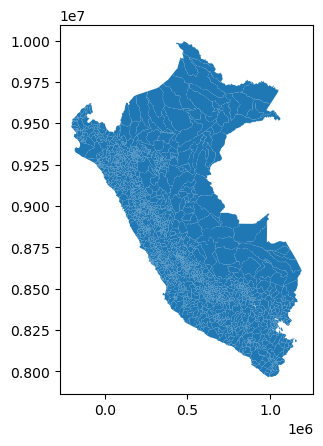

In [5]:
peru_distritos=peru_distritos.to_crs(32718)
peru_distritos.plot()

Besides the spatial units (DEPARTAMEN, PROVINCIA, DISTRITO, and Ubigeo - "Ubigeo" is a code ), you have:
 - **Poblacion**: Population (2017)
 - **Superficie**: Area               
 - **IDH2019**: Human Development Index for DISTRITO (2019)                   
 - **Educ_sec_comp2019_pct**: Share of Population that finished High-School (2019)     
 - **NBI2017_pct**: Share of Population with poverty at the household level aggregated by DISTRITO. This index ("Unsatisfied Basic Needs") uses observable living conditions rather than income alone (2017).
 - **Viv_sin_serv_hig2017_pct**: Share of housing units that have no sanitation infrastructure aggregated by  DISTRITO (2017)


In [16]:
peru_distritos.PROVINCIA.unique()

array(['TACNA', 'JORGE BASADRE', 'ILO', 'TARATA', 'CANDARAVE',
       'MARISCAL NIETO', 'ISLAY', 'EL COLLAO', 'CHUCUITO',
       'GENERAL SANCHEZ CERRO', 'CAMANA', 'AREQUIPA', 'YUNGUYO',
       'CASTILLA', 'CAYLLOMA', 'PUNO', 'CONDESUYOS', 'CARAVELI',
       'SAN ROMAN', 'LAMPA', 'MOHO', 'HUANCANE', 'LA UNION',
       'PAUCAR DEL SARA SARA', 'AZANGARO', 'PARINACOCHAS', 'ESPINAR',
       'NAZCA', 'SAN ANTONIO DE PUTINA', 'MELGAR', 'LUCANAS', 'PALPA',
       'CANAS', 'SANDIA', 'CHUMBIVILCAS', 'ANTABAMBA', 'AYMARAES',
       'CANCHIS', 'ICA', 'GRAU', 'CARABAYA', 'SUCRE', 'COTABAMBAS',
       'ANDAHUAYLAS', 'ACOMAYO', 'VICTOR FAJARDO', 'PARURO', 'HUAYTARA',
       'ABANCAY', 'VILCAS-HUAMAN', 'QUISPICANCHI', 'HUANCA SANCOS',
       'PISCO', 'CHINCHEROS', 'CUSCO', 'ANTA', 'CANGALLO', 'PAUCARTAMBO',
       'CHINCHA', 'CALCA', 'URUBAMBA', 'CASTROVIRREYNA', 'HUAMANGA',
       'LA MAR', 'ANGARAES', 'CANETE', 'LA CONVENCION', 'YAUYOS',
       'HUANTA', 'HUANCAVELICA', 'MANU', 'ACOBAMBA', 'CHURCAM

<Axes: >

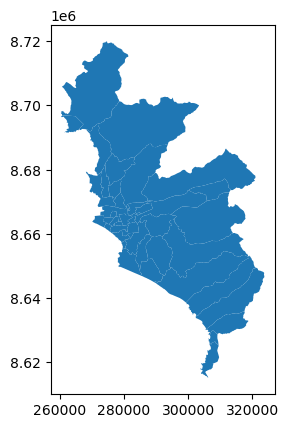

In [17]:
lima_distritos=peru_distritos[peru_distritos.PROVINCIA=='LIMA']
lima_distritos.plot()

In [18]:
lima_distritos.head()

,DEPARTAMEN,PROVINCIA,DISTRITO,Ubigeo,Poblacion,Superficie,IDH2019,Educ_sec_comp2019_pct,NBI2017_pct,Viv_sin_serv_hig2017_pct,geometry
1824,LIMA,LIMA,SANTA ROSA,150139,20112,21.35,0.660577,67.618560,26.5,1.3,"MULTIPOLYGON (((261960.117 8696842.752, 264904..."
1825,LIMA,LIMA,PUENTE PIEDRA,150125,378910,72.81,0.663263,73.192237,23.3,3.2,"MULTIPOLYGON (((272191.963 8692285.904, 272241..."
1827,LIMA,LIMA,SAN JUAN DE LURIGANCHO,150132,1156300,131.25,0.701053,73.146948,19.4,1.1,"MULTIPOLYGON (((289637.339 8687050.968, 289961..."
1828,LIMA,LIMA,LURIGANCHO,150118,232902,236.47,0.683195,74.490008,22.9,5.9,"MULTIPOLYGON (((313665.59 8684817.31, 313722.6..."
1829,LIMA,LIMA,COMAS,150110,545685,48.75,0.721893,77.958189,15.3,0.9,"MULTIPOLYGON (((277067.188 8684376.291, 276904..."


In [20]:
lima_distritos.geometry.apply\
(lambda state: lima_distritos.distance(state)/1000)

,1824,1825,1827,1828,1829,1830,1831,1833,1834,1835,...,1863,1864,1865,1866,1867,1868,1869,1870,1871,1873
1824,0.000000,1.886130,18.905165,25.974327,12.736866,13.455358,12.739095,38.652130,19.455196,30.935649,...,68.100092,73.146459,74.917375,77.188590,51.335417,45.237649,38.935416,0.000000,4.548562,34.098664
1825,1.886130,0.000000,5.979401,13.314200,0.000000,0.000000,0.000000,26.368673,4.460268,16.221720,...,53.178089,58.318901,59.917548,62.060997,36.376980,29.982513,25.391888,0.000000,0.000000,19.232501
1827,18.905165,5.979401,0.000000,0.000000,0.000000,3.345331,2.422548,11.293703,0.000000,0.222601,...,37.729269,42.883584,45.023467,47.643198,21.791238,17.443336,8.448550,14.213752,0.000000,5.467124
1828,25.974327,13.314200,0.000000,0.000000,5.653446,9.885964,8.652744,0.000000,6.460289,0.000000,...,24.808706,37.833862,43.072482,46.094461,19.092582,17.638700,1.029323,21.904086,7.313506,5.994995
1829,12.736866,0.000000,0.000000,5.653446,0.000000,0.000000,1.305872,18.500411,0.000000,10.722373,...,47.950454,52.977715,54.867930,57.284846,31.333468,25.591020,18.766700,9.700930,0.000000,14.183187
1830,13.455358,0.000000,3.345331,9.885964,0.000000,0.000000,0.000000,24.532103,0.000000,9.031582,...,45.797157,50.970347,52.503390,54.608723,29.005052,22.525619,19.871946,11.237876,3.638558,11.923992
1831,12.739095,0.000000,2.422548,8.652744,1.305872,0.000000,0.000000,23.097727,0.000000,5.531827,...,41.952078,47.148175,48.640462,50.723034,25.178566,18.644550,17.232787,12.551723,5.918592,8.219015
1833,38.652130,26.368673,11.293703,0.000000,18.500411,24.532103,23.097727,0.000000,21.074021,0.000000,...,24.473170,35.758672,40.211734,43.631158,16.261800,23.992765,0.000000,33.283698,15.432092,16.151660
1834,19.455196,4.460268,0.000000,6.460289,0.000000,0.000000,0.000000,21.074021,0.000000,7.170083,...,44.034429,49.187996,50.767511,52.920891,27.234564,20.994320,17.187631,17.284325,5.561805,10.107867
1835,30.935649,16.221720,0.222601,0.000000,10.722373,9.031582,5.531827,0.000000,7.170083,0.000000,...,25.560290,34.513340,38.236815,41.164897,15.989843,11.589871,0.000000,28.194614,14.283414,0.000000


In [21]:
lima_distritos.set_index('DISTRITO',inplace=True)
lima_distritos.head()

,DEPARTAMEN,PROVINCIA,Ubigeo,Poblacion,Superficie,IDH2019,Educ_sec_comp2019_pct,NBI2017_pct,Viv_sin_serv_hig2017_pct,geometry
DISTRITO,,,,,,,,,,
SANTA ROSA,LIMA,LIMA,150139,20112,21.35,0.660577,67.618560,26.5,1.3,"MULTIPOLYGON (((261960.117 8696842.752, 264904..."
PUENTE PIEDRA,LIMA,LIMA,150125,378910,72.81,0.663263,73.192237,23.3,3.2,"MULTIPOLYGON (((272191.963 8692285.904, 272241..."
SAN JUAN DE LURIGANCHO,LIMA,LIMA,150132,1156300,131.25,0.701053,73.146948,19.4,1.1,"MULTIPOLYGON (((289637.339 8687050.968, 289961..."
LURIGANCHO,LIMA,LIMA,150118,232902,236.47,0.683195,74.490008,22.9,5.9,"MULTIPOLYGON (((313665.59 8684817.31, 313722.6..."
COMAS,LIMA,LIMA,150110,545685,48.75,0.721893,77.958189,15.3,0.9,"MULTIPOLYGON (((277067.188 8684376.291, 276904..."


In [ ]:
peru_good=gpd.read_file(peruDataLink,layer='good_geom')

You can see roughly the distances here:

### Binary Contiguity

Take a look at the **queen** and **rook** relationship:

<center><img src="https://github.com/CienciaDeDatosEspacial/spatial_autoCorr/raw/main/rookQueen.png" width="700"></center>

From the image above:
- Your **rook** neighbor is whichever  shares a border with you (a borderline of at least two points). It is also known as the _Von Neumann_ neighbor.

- Your **queen** neighbor is whichever  shares a border or a corner with you (at least one point).It is also known as the _Moore_ neighbor.

Let's see how to get each set of neighbors

In [23]:
from libpysal.graph import Graph

# also for reproducibility!
from numpy.random import seed
seed(42)

In [25]:
rook=Graph.build_contiguity(lima_distritos,rook=True) # rook by default

Now let's check the ouput:

**a. adjacency**

In [26]:
rook.adjacency

focal              neighbor              
SANTA ROSA         ANCON                     1
PUENTE PIEDRA      COMAS                     1
                   LOS OLIVOS                1
                   SAN MARTIN DE PORRES      1
                   ANCON                     1
                                            ..
SANTIAGO DE SURCO  SURQUILLO                 1
                   MIRAFLORES                1
                   SAN JUAN DE MIRAFLORES    1
                   BARRANCO                  1
                   CHORRILLOS                1
Name: weight, Length: 190, dtype: int64

The previous results shows only the neighbors of the focals, to recreate a wide format:

In [27]:
import pandas as pd
pd.DataFrame(rook.adjacency).unstack()

weight                                       \
neighbor                SANTA ROSA PUENTE PIEDRA SAN JUAN DE LURIGANCHO   
focal                                                                     
SANTA ROSA                     NaN           NaN                    NaN   
PUENTE PIEDRA                  NaN           NaN                    NaN   
SAN JUAN DE LURIGANCHO         NaN           NaN                    NaN   
LURIGANCHO                     NaN           NaN                    1.0   
COMAS                          NaN           1.0                    1.0   
LOS OLIVOS                     NaN           1.0                    NaN   
SAN MARTIN DE PORRES           NaN           1.0                    NaN   
CHACLACAYO                     NaN           NaN                    NaN   
INDEPENDENCIA                  NaN           NaN                    1.0   
ATE                            NaN           NaN                    NaN   
RIMAC                          NaN           NaN                    1.0   
EL AGUSTINO                    NaN           NaN                    1.0   
SANTA ANITA                    NaN           NaN                    NaN   
LIMA                           NaN           NaN                    1.0   
BRENA                          NaN           NaN                    NaN   
LA MOLINA                      NaN           NaN                    NaN   
LA VICTORIA                    NaN           NaN                    NaN   
SAN LUIS                       NaN           NaN                    NaN   
PACHACAMAC                     NaN           NaN                    NaN   
SAN MIGUEL                     NaN           NaN                    NaN   
JESUS MARIA                    NaN           NaN                    NaN   
MAGDALENA VIEJA                NaN           NaN                    NaN   
LINCE                          NaN           NaN                    NaN   
SAN BORJA                      NaN           NaN                    NaN   
MAGDALENA DEL MAR              NaN           NaN                    NaN   
SAN ISIDRO                     NaN           NaN                    NaN   
SURQUILLO                      NaN           NaN                    NaN   
MIRAFLORES                     NaN           NaN                    NaN   
SAN JUAN DE MIRAFLORES         NaN           NaN                    NaN   
VILLA MARIA DEL TRIUNFO        NaN           NaN                    NaN   
BARRANCO                       NaN           NaN                    NaN   
CHORRILLOS                     NaN           NaN                    NaN   
PUNTA HERMOSA                  NaN           NaN                    NaN   
PUNTA NEGRA                    NaN           NaN                    NaN   
SAN BARTOLO                    NaN           NaN                    NaN   
SANTA MARIA DEL MAR            NaN           NaN                    NaN   
PUCUSANA                       NaN           NaN                    NaN   
LURIN                          NaN           NaN                    NaN   
VILLA EL SALVADOR              NaN           NaN                    NaN   
CIENEGUILLA                    NaN           NaN                    NaN   
ANCON                          1.0           1.0                    NaN   
CARABAYLLO                     NaN           1.0                    1.0   
SANTIAGO DE SURCO              NaN           NaN                    NaN   

                                                                          \
neighbor                LURIGANCHO COMAS LOS OLIVOS SAN MARTIN DE PORRES   
focal                                                                      
SANTA ROSA                     NaN   NaN        NaN                  NaN   
PUENTE PIEDRA                  NaN   1.0        1.0                  1.0   
SAN JUAN DE LURIGANCHO         1.0   1.0        NaN                  NaN   
LURIGANCHO                     NaN   NaN        NaN                  NaN   
COMAS                          NaN   NaN     

We generally fill those missing values (not a neighbor) with zero.

In [28]:
rook_Matrix=pd.DataFrame(rook.adjacency).unstack().fillna(0)
rook_Matrix

weight                                       \
neighbor                SANTA ROSA PUENTE PIEDRA SAN JUAN DE LURIGANCHO   
focal                                                                     
SANTA ROSA                     0.0           0.0                    0.0   
PUENTE PIEDRA                  0.0           0.0                    0.0   
SAN JUAN DE LURIGANCHO         0.0           0.0                    0.0   
LURIGANCHO                     0.0           0.0                    1.0   
COMAS                          0.0           1.0                    1.0   
LOS OLIVOS                     0.0           1.0                    0.0   
SAN MARTIN DE PORRES           0.0           1.0                    0.0   
CHACLACAYO                     0.0           0.0                    0.0   
INDEPENDENCIA                  0.0           0.0                    1.0   
ATE                            0.0           0.0                    0.0   
RIMAC                          0.0           0.0                    1.0   
EL AGUSTINO                    0.0           0.0                    1.0   
SANTA ANITA                    0.0           0.0                    0.0   
LIMA                           0.0           0.0                    1.0   
BRENA                          0.0           0.0                    0.0   
LA MOLINA                      0.0           0.0                    0.0   
LA VICTORIA                    0.0           0.0                    0.0   
SAN LUIS                       0.0           0.0                    0.0   
PACHACAMAC                     0.0           0.0                    0.0   
SAN MIGUEL                     0.0           0.0                    0.0   
JESUS MARIA                    0.0           0.0                    0.0   
MAGDALENA VIEJA                0.0           0.0                    0.0   
LINCE                          0.0           0.0                    0.0   
SAN BORJA                      0.0           0.0                    0.0   
MAGDALENA DEL MAR              0.0           0.0                    0.0   
SAN ISIDRO                     0.0           0.0                    0.0   
SURQUILLO                      0.0           0.0                    0.0   
MIRAFLORES                     0.0           0.0                    0.0   
SAN JUAN DE MIRAFLORES         0.0           0.0                    0.0   
VILLA MARIA DEL TRIUNFO        0.0           0.0                    0.0   
BARRANCO                       0.0           0.0                    0.0   
CHORRILLOS                     0.0           0.0                    0.0   
PUNTA HERMOSA                  0.0           0.0                    0.0   
PUNTA NEGRA                    0.0           0.0                    0.0   
SAN BARTOLO                    0.0           0.0                    0.0   
SANTA MARIA DEL MAR            0.0           0.0                    0.0   
PUCUSANA                       0.0           0.0                    0.0   
LURIN                          0.0           0.0                    0.0   
VILLA EL SALVADOR              0.0           0.0                    0.0   
CIENEGUILLA                    0.0           0.0                    0.0   
ANCON                          1.0           1.0                    0.0   
CARABAYLLO                     0.0           1.0                    1.0   
SANTIAGO DE SURCO              0.0           0.0                    0.0   

                                                                          \
neighbor                LURIGANCHO COMAS LOS OLIVOS SAN MARTIN DE PORRES   
focal                                                                      
SANTA ROSA                     0.0   0.0        0.0                  0.0   
PUENTE PIEDRA                  0.0   1.0        1.0                  1.0   
SAN JUAN DE LURIGANCHO         1.0   1.0        0.0                  0.0   
LURIGANCHO                     0.0   0.0        0.0                  0.0   
COMAS                          0.0   0.0     

Notice we created this wide matrix for pedagogical purposes. It is a bad idea if you have many columns and rows.

**b. adjacency graph**

As we have a `GRAPH`, we can identify these neighborhood relationships via edges:

In [31]:
##this will be used several times:
general_arguments=dict(gdf=lima_distritos,node_kws=dict(color='red'), edge_kws=dict(alpha=0.4,color='blue'),zoom_start = 11)
rook.explore(**general_arguments)

### Proximity


####  Nearest Neighbors

* The key idea: A focal polygon considers another polygon a neighbor if that second polygon is among the K closest polygons to the focal polygon, where “closeness” is measured by the distance between their geometric centroids (or any other user-supplied distance metric).  
* The input: A GeoDataFrame (GDF) containing polygon geometries. Each row represents a spatial unit that can serve as a focal observation.  
* The process: For each polygon (focal unit), the algorithm (1) computes the distance between its centroid and every other centroid, (2) ranks these distances, and (3) flags the K smallest distances as neighbors. Ties can be broken by random selection, ID order, or by including all tied candidates.  
* The output: A graph built from a binary adjacency matrix where each node represents a polygon (focal unit). An edge exists between two nodes whenever one polygon is among the K nearest neighbors of the other. The corresponding adjacency matrix is binary and, by construction, typically asymmetric unless a symmetric constraint is explicitly enforced. No isolates in output.

If assume K is 3:

**a. adjacency matrix**

In [33]:
knn3 = Graph.build_knn(lima_distritos.representative_point(), # GDF
                                 k=3) # desired k

knn3_Matrix=pd.DataFrame(knn3.adjacency).unstack().fillna(0)
knn3_Matrix

weight                                    \
neighbor                PUENTE PIEDRA COMAS ANCON SANTA ROSA LOS OLIVOS   
focal                                                                     
SANTA ROSA                        1.0   1.0   1.0        0.0        0.0   
PUENTE PIEDRA                     0.0   1.0   0.0        1.0        1.0   
SAN JUAN DE LURIGANCHO            0.0   1.0   0.0        0.0        0.0   
LURIGANCHO                        0.0   0.0   0.0        0.0        0.0   
COMAS                             0.0   0.0   0.0        0.0        1.0   
LOS OLIVOS                        0.0   1.0   0.0        0.0        0.0   
SAN MARTIN DE PORRES              0.0   0.0   0.0        0.0        1.0   
CHACLACAYO                        0.0   0.0   0.0        0.0        0.0   
INDEPENDENCIA                     0.0   0.0   0.0        0.0        1.0   
ATE                               0.0   0.0   0.0        0.0        0.0   
RIMAC                             0.0   0.0   0.0        0.0        0.0   
EL AGUSTINO                       0.0   0.0   0.0        0.0        0.0   
SANTA ANITA                       0.0   0.0   0.0        0.0        0.0   
LIMA                              0.0   0.0   0.0        0.0        0.0   
BRENA                             0.0   0.0   0.0        0.0        0.0   
LA MOLINA                         0.0   0.0   0.0        0.0        0.0   
LA VICTORIA                       0.0   0.0   0.0        0.0        0.0   
SAN LUIS                          0.0   0.0   0.0        0.0        0.0   
PACHACAMAC                        0.0   0.0   0.0        0.0        0.0   
SAN MIGUEL                        0.0   0.0   0.0        0.0        0.0   
JESUS MARIA                       0.0   0.0   0.0        0.0        0.0   
MAGDALENA VIEJA                   0.0   0.0   0.0        0.0        0.0   
LINCE                             0.0   0.0   0.0        0.0        0.0   
SAN BORJA                         0.0   0.0   0.0        0.0        0.0   
MAGDALENA DEL MAR                 0.0   0.0   0.0        0.0        0.0   
SAN ISIDRO                        0.0   0.0   0.0        0.0        0.0   
SURQUILLO                         0.0   0.0   0.0        0.0        0.0   
MIRAFLORES                        0.0   0.0   0.0        0.0        0.0   
SAN JUAN DE MIRAFLORES            0.0   0.0   0.0        0.0        0.0   
VILLA MARIA DEL TRIUNFO           0.0   0.0   0.0        0.0        0.0   
BARRANCO                          0.0   0.0   0.0        0.0        0.0   
CHORRILLOS                        0.0   0.0   0.0        0.0        0.0   
PUNTA HERMOSA                     0.0   0.0   0.0        0.0        0.0   
PUNTA NEGRA                       0.0   0.0   0.0        0.0        0.0   
SAN BARTOLO                       0.0   0.0   0.0        0.0        0.0   
SANTA MARIA DEL MAR               0.0   0.0   0.0        0.0        0.0   
PUCUSANA                          0.0   0.0   0.0        0.0        0.0   
LURIN                             0.0   0.0   0.0        0.0        0.0   
VILLA EL SALVADOR                 0.0   0.0   0.0        0.0        0.0   
CIENEGUILLA                       0.0   0.0   0.0        0.0        0.0   
ANCON                             1.0   0.0   0.0        1.0        0.0   
CARABAYLLO                        1.0   1.0   0.0        0.0        0.0   
SANTIAGO DE SURCO                 0.0   0.0   0.0        0.0        0.0   

                                                                         ...  \
neighbor                INDEPENDENCIA RIMAC CHACLACAYO  ATE CIENEGUILLA  ...   
focal                                                                    ...   
SANTA ROSA                        0.0   0.0        0.0  0.0         0.0  ...   
PUENTE PIEDRA                     0.0   0.0        0.0  0.0         0.0  ...   
SAN JUAN DE LURIGANCHO            1.0   1.0        0.0  0.0         0.0  ...   
LURIGANCHO                        0.0   0.0        1.0  1.0         1.0  ...   
COMAS               

**b. adjacency plot**

In [34]:
knn3.explore(**general_arguments)

## II. Neighborhoods as weights

Our matrices tell us which are neighbors, and some give us additional information related to the 'farness' of the identified neighbor. Let me compute the marginal values by row (sum):

In [35]:
allMx=[rook_Matrix.sum(axis=1),
       knn3_Matrix.sum(axis=1)]
pd.concat(allMx,axis=1)

,0,1
focal,,
SANTA ROSA,1.0,3.0
PUENTE PIEDRA,5.0,3.0
SAN JUAN DE LURIGANCHO,7.0,3.0
LURIGANCHO,4.0,3.0
COMAS,5.0,3.0
LOS OLIVOS,4.0,3.0
SAN MARTIN DE PORRES,5.0,3.0
CHACLACAYO,3.0,3.0
INDEPENDENCIA,5.0,3.0


We know that no-neighbors have value zero in the matrix. Then, non-zero values carries some weight. However, they are currently not normalized (they do not add to 1 by row), which may bias further procedures as raw values may 'distort' mathematical modelling.


But this binary matrix is normalized (by **r**ows):

In [37]:
rook.transform("r")

<Graph of 43 nodes and 190 nonzero edges (1 component, 0 isolates) indexed by
 ['SANTA ROSA', 'PUENTE PIEDRA', 'SAN JUAN DE LURIGANCHO', 'LURIGANCHO', ...]>

In [40]:
pd.DataFrame(rook.transform("r").adjacency).unstack().fillna(0)

weight                                       \
neighbor                SANTA ROSA PUENTE PIEDRA SAN JUAN DE LURIGANCHO   
focal                                                                     
SANTA ROSA                0.000000      0.000000               0.000000   
PUENTE PIEDRA             0.000000      0.000000               0.000000   
SAN JUAN DE LURIGANCHO    0.000000      0.000000               0.000000   
LURIGANCHO                0.000000      0.000000               0.250000   
COMAS                     0.000000      0.200000               0.200000   
LOS OLIVOS                0.000000      0.250000               0.000000   
SAN MARTIN DE PORRES      0.000000      0.200000               0.000000   
CHACLACAYO                0.000000      0.000000               0.000000   
INDEPENDENCIA             0.000000      0.000000               0.200000   
ATE                       0.000000      0.000000               0.000000   
RIMAC                     0.000000      0.000000               0.250000   
EL AGUSTINO               0.000000      0.000000               0.166667   
SANTA ANITA               0.000000      0.000000               0.000000   
LIMA                      0.000000      0.000000               0.100000   
BRENA                     0.000000      0.000000               0.000000   
LA MOLINA                 0.000000      0.000000               0.000000   
LA VICTORIA               0.000000      0.000000               0.000000   
SAN LUIS                  0.000000      0.000000               0.000000   
PACHACAMAC                0.000000      0.000000               0.000000   
SAN MIGUEL                0.000000      0.000000               0.000000   
JESUS MARIA               0.000000      0.000000               0.000000   
MAGDALENA VIEJA           0.000000      0.000000               0.000000   
LINCE                     0.000000      0.000000               0.000000   
SAN BORJA                 0.000000      0.000000               0.000000   
MAGDALENA DEL MAR         0.000000      0.000000               0.000000   
SAN ISIDRO                0.000000      0.000000               0.000000   
SURQUILLO                 0.000000      0.000000               0.000000   
MIRAFLORES                0.000000      0.000000               0.000000   
SAN JUAN DE MIRAFLORES    0.000000      0.000000               0.000000   
VILLA MARIA DEL TRIUNFO   0.000000      0.000000               0.000000   
BARRANCO                  0.000000      0.000000               0.000000   
CHORRILLOS                0.000000      0.000000               0.000000   
PUNTA HERMOSA             0.000000      0.000000               0.000000   
PUNTA NEGRA               0.000000      0.000000               0.000000   
SAN BARTOLO               0.000000      0.000000               0.000000   
SANTA MARIA DEL MAR       0.000000      0.000000               0.000000   
PUCUSANA                  0.000000      0.000000               0.000000   
LURIN                     0.000000      0.000000               0.000000   
VILLA EL SALVADOR         0.000000      0.000000               0.000000   
CIENEGUILLA               0.000000      0.000000               0.000000   
ANCON                     0.333333      0.333333               0.000000   
CARABAYLLO                0.000000      0.250000               0.250000   
SANTIAGO DE SURCO         0.000000      0.000000               0.000000   

                                                                              \
neighbor                LURIGANCHO     COMAS LOS OLIVOS SAN MARTIN DE PORRES   
focal                                                                          
SANTA ROSA                0.000000  0.000000        0.0                 0.00   
PUENTE PIEDRA             0.000000  0.200000        0.2                 0.20   
SAN JUAN DE LURIGANCHO    0.142857  0.142857        0.0                 0.00   
LURIGANCHO                0.000000  0.000000        0.0                 0.00   
COMAS            

## III. How are my neighbors doing...?

The actual question should be related to a social variable, for example, poverty, mortality, education, etc.

For example, this is "how each distrito is doing" related to HS education (share of population that completed high school):

In [43]:
lima_distritos.Educ_sec_comp2019_pct.describe()

count    43.000000
mean     75.512946
std       4.374179
min      64.032471
25%      73.381876
50%      76.479814
75%      78.606621
max      82.555665
Name: Educ_sec_comp2019_pct, dtype: float64

See the choropleth (quantile bining):

<Axes: >

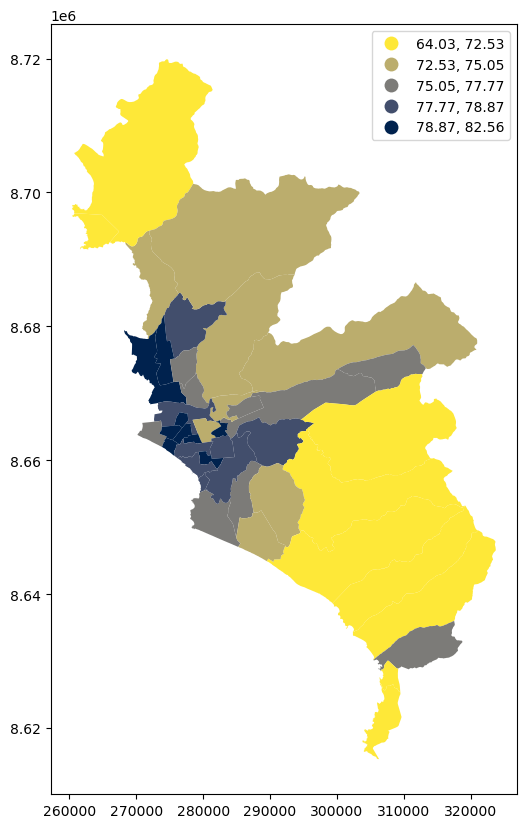

In [45]:
lima_distritos.plot(
    "Educ_sec_comp2019_pct",
    scheme="quantiles",
    cmap="cividis_r",
    legend=True,figsize=(12, 10))

In [46]:
lima_rook=rook.transform("r")

Then,  the spatial lag of the variable "Educ_sec_comp2019_pct" can be obtained like this:

In [48]:
ylag = lima_rook.lag(lima_distritos["Educ_sec_comp2019_pct"])

Let me add it to the GDF:

In [49]:
lima_distritos=lima_distritos.assign(Educ_sec_comp2019_pct_lagged=ylag)
lima_distritos.head()

,DEPARTAMEN,PROVINCIA,Ubigeo,Poblacion,Superficie,IDH2019,Educ_sec_comp2019_pct,NBI2017_pct,Viv_sin_serv_hig2017_pct,geometry,Educ_sec_comp2019_pct_lagged
DISTRITO,,,,,,,,,,,
SANTA ROSA,LIMA,LIMA,150139,20112,21.35,0.660577,67.618560,26.5,1.3,"MULTIPOLYGON (((261960.117 8696842.752, 264904...",72.117976
PUENTE PIEDRA,LIMA,LIMA,150125,378910,72.81,0.663263,73.192237,23.3,3.2,"MULTIPOLYGON (((272191.963 8692285.904, 272241...",76.479130
SAN JUAN DE LURIGANCHO,LIMA,LIMA,150132,1156300,131.25,0.701053,73.146948,19.4,1.1,"MULTIPOLYGON (((289637.339 8687050.968, 289961...",75.647970
LURIGANCHO,LIMA,LIMA,150118,232902,236.47,0.683195,74.490008,22.9,5.9,"MULTIPOLYGON (((313665.59 8684817.31, 313722.6...",75.199131
COMAS,LIMA,LIMA,150110,545685,48.75,0.721893,77.958189,15.3,0.9,"MULTIPOLYGON (((277067.188 8684376.291, 276904...",75.195699


Let's plot HS share against its lag:

<Axes: xlabel='Educ_sec_comp2019_pct', ylabel='Educ_sec_comp2019_pct_lagged'>

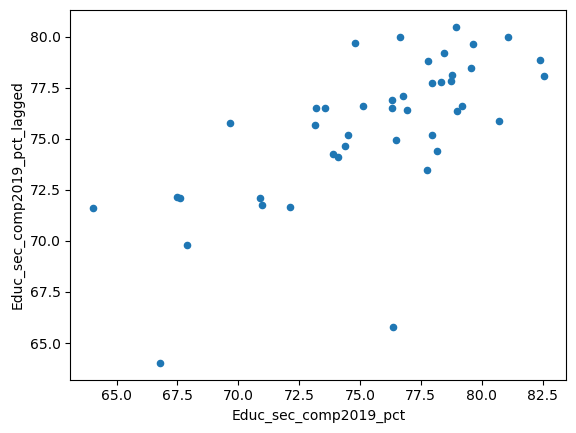

In [50]:
lima_distritos.plot.scatter("Educ_sec_comp2019_pct","Educ_sec_comp2019_pct_lagged")

## IV. Spatial autocorrelation

### IV. 1 Global

A correlation plot as the previous one should let us know if a variable is correlated with values of the neighbors (the lag), and if that were the case,  proximity is interfering statistical analysis, as the variable values are not independent.

The most well known measure to confirm that is the Moran's I index of global spatial correlation. Let's see the value we get:


In [51]:
import esda # from pysal

MoranGlobal_HS = esda.Moran(lima_distritos['Educ_sec_comp2019_pct'], lima_rook)

Once computed, you can retrieve its value and significance:

In [52]:
MoranGlobal_HS.I,MoranGlobal_HS.p_sim

(np.float64(0.5528121374191303), np.float64(0.001))

Moran’s I is interpreted like a Pearson r, but benchmarks are lower:

- |I| > 0.5 → strong, 0.2–0.5 → moderate, < 0.2 → weak.
- Sign indicates positive vs. negative spatial clustering.

Significance is assessed with a pseudo p-value from conditional randomisations of the data, because the theoretical null distribution is unknown for irregular spatial weights.

### IV. 2 Local

We can compute a Local Index of Spatial Association (LISA -local Moran) for each map polygon. That will help us find spatial clusters (spots) and spatial outliers:

- High-High (HH): values above average surrounded by values above average.These are also known as **hotSpot**s.
- Low-Low (LL): values below average surrounded by values below average. These are also known as **coldSpot**s.
- High-Low (HL): values above average surrounded by values below average.These are also known as **hotOutlier**s.
- Low-High (LH): values below average surrounded by values above average. These are also known as **coldOutlier**s.

It is also possible that no significant correlation is detected. Let's see those values:



a. Compute the LISAs:

In [53]:
lima_lisa = esda.Moran_Local(lima_distritos['Educ_sec_comp2019_pct'], lima_rook)


b. Plot the results (**fast way**)

<Axes: >

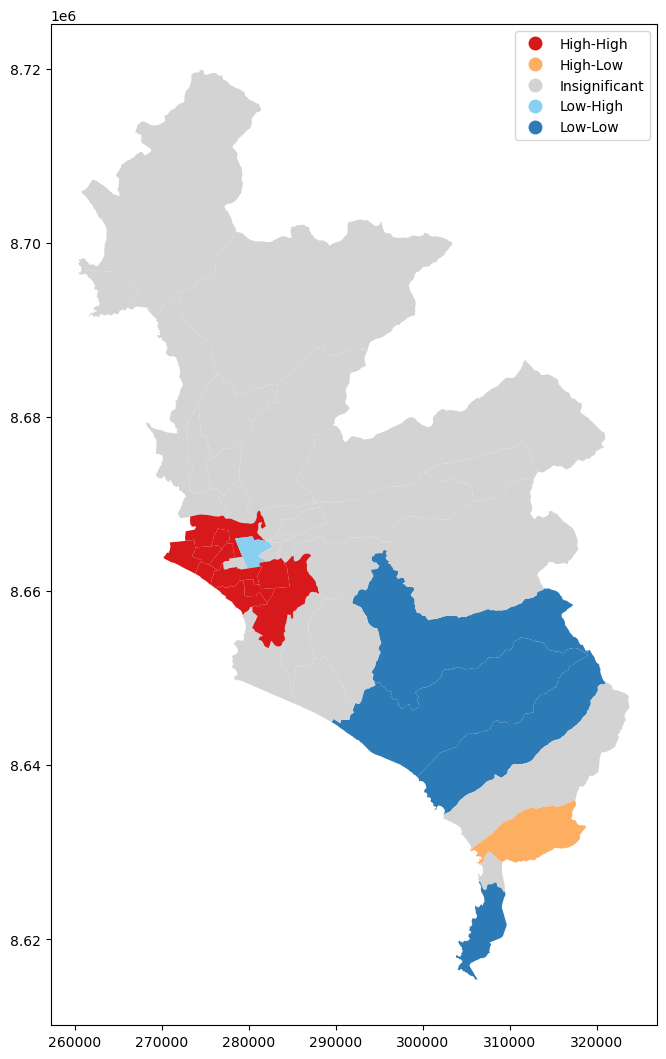

In [54]:
lima_lisa.plot(lima_distritos,crit_value=0.05,figsize=(10,13),legend=True)

#### IV. 2. 1 Analysis Local Spatial Correlation quadrants

You can not get the quadrant labels from the previous plot directly into the original GDF, thus complicating further analysis and exporting of those results.

First let's recover the labels into a new column:

In [55]:
# get the quadrants
lima_distritos['HS_lisa'] = lima_lisa.get_cluster_labels(crit_value=0.05)

In [56]:
# see the count
lima_distritos['HS_lisa'].value_counts()

HS_lisa
Insignificant    26
High-High        11
Low-Low           4
Low-High          1
High-Low          1
Name: count, dtype: int64

Now, we can prepare a comparisson:

#### IV. 2. 2 Customizing Local Spatial Correlation quadrants

At this stage, we can rename the previous column to customize cluster labels and colors:

In [59]:
##knowing
lima_distritos['HS_lisa'].unique()

array(['Insignificant', 'High-High', 'Low-High', 'Low-Low', 'High-Low'],
      dtype=object)

Keep in mind that the outliers may deserve more attention, so they may be at the top or bottom of the levels. You can add a number to achieve this purpose:

In [60]:
oldLabels=['Insignificant', 'Low-Low', 'High-High', 'High-Low', 'Low-High']

# 3 will be at the middle
newLabels = ['3 no_pattern', '4 coldSpot','2 hotSpot','1 hotOutlier' , '5 coldOutlier']

labels = dict(zip(oldLabels, newLabels))

labels

{'Insignificant': '3 no_pattern',
 'Low-Low': '4 coldSpot',
 'High-High': '2 hotSpot',
 'High-Low': '1 hotOutlier',
 'Low-High': '5 coldOutlier'}

Just using this dictionary to rename the column:

In [61]:

lima_distritos.replace({'HS_lisa':labels},inplace=True)

## see the count
lima_distritos['HS_lisa'].value_counts().sort_index()

HS_lisa
1 hotOutlier      1
2 hotSpot        11
3 no_pattern     26
4 coldSpot        4
5 coldOutlier     1
Name: count, dtype: int64

Finally, used that order to assign diverging color-blind safe palette:

<Axes: >

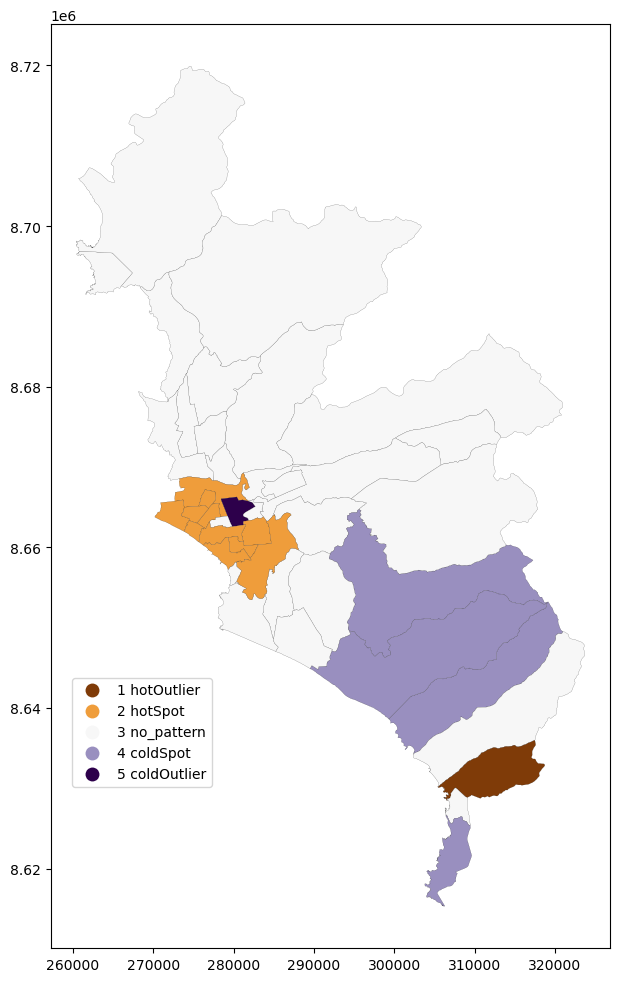

In [63]:
##custom colors- respect the previous order

import matplotlib.pyplot as plt
myColMap = plt.get_cmap('PuOr', 5)


##plot the map

lima_distritos.plot(column='HS_lisa',
                categorical=True,
                cmap=myColMap,
                linewidth=0.1,
                edgecolor='k',
                legend=True,
                legend_kwds={'bbox_to_anchor': (0.3, 0.3)},
                figsize=(12,12))

In [65]:
lima_knn3=knn3.transform("r")
lima_lisa_knn3 = esda.Moran_Local(lima_distritos['Educ_sec_comp2019_pct'], lima_knn3)
lima_distritos['HS_lisa_knn3'] = lima_lisa_knn3.get_cluster_labels(crit_value=0.05)
lima_distritos.replace({'HS_lisa_knn3':labels},inplace=True)

In [69]:
lima_distritos.loc[:,['HS_lisa','HS_lisa_knn3']]

,HS_lisa,HS_lisa_knn3
DISTRITO,,
SANTA ROSA,3 no_pattern,3 no_pattern
PUENTE PIEDRA,3 no_pattern,3 no_pattern
SAN JUAN DE LURIGANCHO,3 no_pattern,3 no_pattern
LURIGANCHO,3 no_pattern,3 no_pattern
COMAS,3 no_pattern,3 no_pattern
LOS OLIVOS,3 no_pattern,3 no_pattern
SAN MARTIN DE PORRES,3 no_pattern,3 no_pattern
CHACLACAYO,3 no_pattern,3 no_pattern
INDEPENDENCIA,3 no_pattern,3 no_pattern


In [71]:
lima_distritos[lima_distritos.HS_lisa!=lima_distritos.HS_lisa_knn3]

,DEPARTAMEN,PROVINCIA,Ubigeo,Poblacion,Superficie,IDH2019,Educ_sec_comp2019_pct,NBI2017_pct,Viv_sin_serv_hig2017_pct,geometry,Educ_sec_comp2019_pct_lagged,HS_lisa,HS_lisa_knn3
DISTRITO,,,,,,,,,,,,,
LIMA,LIMA,LIMA,150101,269858,21.98,0.764685,77.960827,10.6,0.0,"MULTIPOLYGON (((281758.224 8668043.314, 281956...",77.727153,2 hotSpot,3 no_pattern
SAN BORJA,LIMA,LIMA,150130,114479,9.96,0.823616,78.762975,2.1,0.0,"MULTIPOLYGON (((283845.076 8663624.975, 283848...",78.098269,2 hotSpot,3 no_pattern
SURQUILLO,LIMA,LIMA,150141,92908,3.46,0.817114,79.576586,6.4,0.0,"MULTIPOLYGON (((280697.081 8660718.983, 280728...",78.440079,2 hotSpot,3 no_pattern
MIRAFLORES,LIMA,LIMA,150122,82898,9.62,0.832640,77.784099,1.2,0.0,"MULTIPOLYGON (((279465.859 8660533.526, 279503...",78.784262,2 hotSpot,3 no_pattern
PUNTA HERMOSA,LIMA,LIMA,150126,8104,119.50,0.695989,67.896270,37.8,1.6,"MULTIPOLYGON (((320821.834 8649274.803, 320792...",69.786136,4 coldSpot,3 no_pattern
SANTA MARIA DEL MAR,LIMA,LIMA,150138,1721,9.81,0.746660,64.032471,12.1,0.0,"MULTIPOLYGON (((309107 8628824, 309127 8628763...",71.583589,3 no_pattern,4 coldSpot
SANTIAGO DE SURCO,LIMA,LIMA,150140,363183,35.89,0.801757,78.743024,3.6,0.1,"MULTIPOLYGON (((286939.161 8664275.918, 286939...",77.827372,2 hotSpot,3 no_pattern
